In [39]:
# ============================================================
# Notebook 06 - Simulación de escenarios de límites
# Carga de ventanas de 30 días exportadas desde Notebook 03
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

OUTPUT_PATH = Path("outputs")

df_preguntas_limites = pd.read_csv(OUTPUT_PATH / "df_preguntas_limites.csv")
df_flashcards_limites = pd.read_csv(OUTPUT_PATH / "df_flashcards_limites.csv")
df_chat_limites = pd.read_csv(OUTPUT_PATH / "df_chat_limites.csv")

print("Preguntas:", df_preguntas_limites.shape)
print("Flashcards:", df_flashcards_limites.shape)
print("Chat:", df_chat_limites.shape)

print(df_preguntas_limites.head())
print(df_flashcards_limites.head())
print(df_chat_limites.head())

Preguntas: (17496, 4)
Flashcards: (5607, 4)
Chat: (2462, 5)
                                user_id  ventana_30d  preguntas_ia  \
0  006adeba-8e9a-7c9b-80b3-28168e0cbdef            0            75   
1  00eda2d5-8fa1-7ac4-9fe9-5eacee342013            0            30   
2  010836c7-d25d-76de-8a17-02a187087283            0          1156   
3  010836c7-d25d-76de-8a17-02a187087283            1           270   
4  010836c7-d25d-76de-8a17-02a187087283            7           185   

   supera_limite  
0          False  
1          False  
2           True  
3           True  
4          False  
                                user_id  ventana_30d  cards_generadas  \
0  010836c7-d25d-76de-8a17-02a187087283            7               54   
1  0199e73a-7d69-76dd-a457-e0bf3f438b48            2              560   
2  0199f8a4-1857-7f59-9f29-48f06756a1a1            3               65   
3  019a021a-304d-741c-9e51-2af5deae1cba            2               53   
4  019a4a82-6540-7f8b-a6c9-bca9ed1dfba7 

Ventanas usuario-30d: 20039
Usuarios únicos: 19608


,user_id,ventana_30d,n_preguntas_ia,n_flashcards,coste_chat_usd,n_mensajes
0,006adeba-8e9a-7c9b-80b3-28168e0cbdef,0,75.0000,0.0000,0.0000,0.0000
1,00eda2d5-8fa1-7ac4-9fe9-5eacee342013,0,30.0000,0.0000,0.0000,0.0000
2,010836c7-d25d-76de-8a17-02a187087283,0,"1,156.0000",0.0000,0.0000,0.0000
3,010836c7-d25d-76de-8a17-02a187087283,1,270.0000,0.0000,0.0000,0.0000
4,010836c7-d25d-76de-8a17-02a187087283,7,185.0000,54.0000,0.0000,0.0000


In [25]:
# ============================================================
# Escenarios de límites gratuitos
# ============================================================

escenarios = pd.DataFrame([
    {
        "escenario": "Actual",
        "lim_preguntas": 250,
        "lim_flashcards": 500,
        "lim_chat_usd": 0.05
    },
    {
        "escenario": "Moderado",
        "lim_preguntas": 150,
        "lim_flashcards": 300,
        "lim_chat_usd": 0.04
    },
    {
        "escenario": "Agresivo",
        "lim_preguntas": 100,
        "lim_flashcards": 200,
        "lim_chat_usd": 0.03
    },
    {
        "escenario": "Selectivo chat",
        "lim_preguntas": 250,
        "lim_flashcards": 500,
        "lim_chat_usd": 0.03
    }
])

resultados = []

for _, esc in escenarios.iterrows():
    df = ventanas_free.copy()

    df["supera_preguntas"] = df["n_preguntas_ia"] > esc["lim_preguntas"]
    df["supera_flashcards"] = df["n_flashcards"] > esc["lim_flashcards"]
    df["supera_chat"] = df["coste_chat_usd"] > esc["lim_chat_usd"]

    df["supera_alguno"] = (
        df["supera_preguntas"] |
        df["supera_flashcards"] |
        df["supera_chat"]
    )

    usuarios_base = df["user_id"].nunique()
    usuarios_afectados = df.loc[df["supera_alguno"], "user_id"].nunique()

    resultados.append({
        "escenario": esc["escenario"],
        "lim_preguntas": esc["lim_preguntas"],
        "lim_flashcards": esc["lim_flashcards"],
        "lim_chat_usd": esc["lim_chat_usd"],
        "usuarios_base": usuarios_base,
        "usuarios_afectados": usuarios_afectados,
        "pct_usuarios_afectados": usuarios_afectados / usuarios_base * 100,
        "usuarios_afectados_preguntas": df.loc[df["supera_preguntas"], "user_id"].nunique(),
        "usuarios_afectados_flashcards": df.loc[df["supera_flashcards"], "user_id"].nunique(),
        "usuarios_afectados_chat": df.loc[df["supera_chat"], "user_id"].nunique(),
        "ventanas_afectadas": df["supera_alguno"].sum()
    })

simulacion_ventanas = pd.DataFrame(resultados)

afectados_actual = simulacion_ventanas.loc[
    simulacion_ventanas["escenario"] == "Actual",
    "usuarios_afectados"
].iloc[0]

simulacion_ventanas["usuarios_incrementales_vs_actual"] = (
    simulacion_ventanas["usuarios_afectados"] - afectados_actual
)

simulacion_ventanas.round(2)

,escenario,lim_preguntas,lim_flashcards,lim_chat_usd,usuarios_base,usuarios_afectados,pct_usuarios_afectados,usuarios_afectados_preguntas,usuarios_afectados_flashcards,usuarios_afectados_chat,ventanas_afectadas,usuarios_incrementales_vs_actual
0,Actual,250,500,0.0500,19608,863,4.4000,611,201,82,895,0
1,Moderado,150,300,0.0400,19608,4126,21.0400,3742,520,123,4202,3263
2,Agresivo,100,200,0.0300,19608,5853,29.8500,5185,986,280,5968,4990
3,Selectivo chat,250,500,0.0300,19608,1053,5.3700,611,201,280,1092,190


In [26]:
# ============================================================
# Impacto estimado en conversión y KPIs
# ============================================================

USUARIOS_TOTALES = 32636
USUARIOS_QUE_PAGARON = 619

ARPPU_NETO = 6.66
LTV_ESTIMADO = 18.46

tasas_conversion_supuestas = {
    "conservador_5pct": 0.05,
    "medio_10pct": 0.10,
    "optimista_20pct": 0.20
}

impacto_ventanas = simulacion_ventanas.copy()

for nombre, tasa in tasas_conversion_supuestas.items():
    impacto_ventanas[f"conversiones_incrementales_{nombre}"] = (
        impacto_ventanas["usuarios_incrementales_vs_actual"].clip(lower=0) * tasa
    )

    impacto_ventanas[f"usuarios_pago_total_{nombre}"] = (
        USUARIOS_QUE_PAGARON + impacto_ventanas[f"conversiones_incrementales_{nombre}"]
    )

    impacto_ventanas[f"tasa_conversion_total_{nombre}"] = (
        impacto_ventanas[f"usuarios_pago_total_{nombre}"] /
        USUARIOS_TOTALES * 100
    )

    impacto_ventanas[f"ingreso_mensual_incremental_{nombre}"] = (
        impacto_ventanas[f"conversiones_incrementales_{nombre}"] * ARPPU_NETO
    )

    impacto_ventanas[f"ltv_incremental_{nombre}"] = (
        impacto_ventanas[f"conversiones_incrementales_{nombre}"] * LTV_ESTIMADO
    )

impacto_ventanas.round(2)

,escenario,lim_preguntas,lim_flashcards,lim_chat_usd,usuarios_base,usuarios_afectados,pct_usuarios_afectados,usuarios_afectados_preguntas,usuarios_afectados_flashcards,usuarios_afectados_chat,ventanas_afectadas,usuarios_incrementales_vs_actual,conversiones_incrementales_conservador_5pct,usuarios_pago_total_conservador_5pct,tasa_conversion_total_conservador_5pct,ingreso_mensual_incremental_conservador_5pct,ltv_incremental_conservador_5pct,conversiones_incrementales_medio_10pct,usuarios_pago_total_medio_10pct,tasa_conversion_total_medio_10pct,ingreso_mensual_incremental_medio_10pct,ltv_incremental_medio_10pct,conversiones_incrementales_optimista_20pct,usuarios_pago_total_optimista_20pct,tasa_conversion_total_optimista_20pct,ingreso_mensual_incremental_optimista_20pct,ltv_incremental_optimista_20pct
0,Actual,250,500,0.0500,19608,863,4.4000,611,201,82,895,0,0.0000,619.0000,1.9000,0.0000,0.0000,0.0000,619.0000,1.9000,0.0000,0.0000,0.0000,619.0000,1.9000,0.0000,0.0000
1,Moderado,150,300,0.0400,19608,4126,21.0400,3742,520,123,4202,3263,163.1500,782.1500,2.4000,"1,086.5800","3,011.7500",326.3000,945.3000,2.9000,"2,173.1600","6,023.5000",652.6000,"1,271.6000",3.9000,"4,346.3200","12,047.0000"
2,Agresivo,100,200,0.0300,19608,5853,29.8500,5185,986,280,5968,4990,249.5000,868.5000,2.6600,"1,661.6700","4,605.7700",499.0000,"1,118.0000",3.4300,"3,323.3400","9,211.5400",998.0000,"1,617.0000",4.9500,"6,646.6800","18,423.0800"
3,Selectivo chat,250,500,0.0300,19608,1053,5.3700,611,201,280,1092,190,9.5000,628.5000,1.9300,63.2700,175.3700,19.0000,638.0000,1.9500,126.5400,350.7400,38.0000,657.0000,2.0100,253.0800,701.4800


In [27]:
# ============================================================
# Tabla compacta para el TFG
# ============================================================

tabla_simulacion_tfg = impacto_ventanas[[
    "escenario",
    "lim_preguntas",
    "lim_flashcards",
    "lim_chat_usd",
    "usuarios_afectados",
    "pct_usuarios_afectados",
    "usuarios_incrementales_vs_actual",
    "conversiones_incrementales_conservador_5pct",
    "conversiones_incrementales_medio_10pct",
    "conversiones_incrementales_optimista_20pct",
    "tasa_conversion_total_conservador_5pct",
    "tasa_conversion_total_medio_10pct",
    "tasa_conversion_total_optimista_20pct",
    "ingreso_mensual_incremental_conservador_5pct",
    "ingreso_mensual_incremental_medio_10pct",
    "ingreso_mensual_incremental_optimista_20pct"
]].copy()

tabla_simulacion_tfg = tabla_simulacion_tfg.rename(columns={
    "escenario": "Escenario",
    "lim_preguntas": "Límite preguntas",
    "lim_flashcards": "Límite flashcards",
    "lim_chat_usd": "Límite chat $",
    "usuarios_afectados": "Usuarios afectados",
    "pct_usuarios_afectados": "% afectados",
    "usuarios_incrementales_vs_actual": "Afectados adicionales",
    "conversiones_incrementales_conservador_5pct": "Conv. incr. 5%",
    "conversiones_incrementales_medio_10pct": "Conv. incr. 10%",
    "conversiones_incrementales_optimista_20pct": "Conv. incr. 20%",
    "tasa_conversion_total_conservador_5pct": "Conv. total 5%",
    "tasa_conversion_total_medio_10pct": "Conv. total 10%",
    "tasa_conversion_total_optimista_20pct": "Conv. total 20%",
    "ingreso_mensual_incremental_conservador_5pct": "Ingreso incr. 5%",
    "ingreso_mensual_incremental_medio_10pct": "Ingreso incr. 10%",
    "ingreso_mensual_incremental_optimista_20pct": "Ingreso incr. 20%"
})

tabla_simulacion_tfg.round(2)

,Escenario,Límite preguntas,Límite flashcards,Límite chat $,Usuarios afectados,% afectados,Afectados adicionales,Conv. incr. 5%,Conv. incr. 10%,Conv. incr. 20%,Conv. total 5%,Conv. total 10%,Conv. total 20%,Ingreso incr. 5%,Ingreso incr. 10%,Ingreso incr. 20%
0,Actual,250,500,0.0500,863,4.4000,0,0.0000,0.0000,0.0000,1.9000,1.9000,1.9000,0.0000,0.0000,0.0000
1,Moderado,150,300,0.0400,4126,21.0400,3263,163.1500,326.3000,652.6000,2.4000,2.9000,3.9000,"1,086.5800","2,173.1600","4,346.3200"
2,Agresivo,100,200,0.0300,5853,29.8500,4990,249.5000,499.0000,998.0000,2.6600,3.4300,4.9500,"1,661.6700","3,323.3400","6,646.6800"
3,Selectivo chat,250,500,0.0300,1053,5.3700,190,9.5000,19.0000,38.0000,1.9300,1.9500,2.0100,63.2700,126.5400,253.0800


In [28]:
# ============================================================
# Exportar resultados
# ============================================================

OUTPUT_PATH = Path("outputs")
OUTPUT_PATH.mkdir(exist_ok=True)

simulacion_ventanas.to_csv(OUTPUT_PATH / "simulacion_ventanas_limites.csv", index=False)
impacto_ventanas.to_csv(OUTPUT_PATH / "impacto_simulacion_limites.csv", index=False)
tabla_simulacion_tfg.to_csv(OUTPUT_PATH / "tabla_simulacion_tfg.csv", index=False)

print("Resultados exportados.")

Resultados exportados.


In [29]:
# ============================================================
# Simulación de conversión incremental con tasas observadas
# ============================================================

# Tasas observadas en el análisis
TASA_CONVERSION_GENERAL = 0.0190

TASA_CONV_PREGUNTAS = 0.044   # usuarios que superaron preguntas y pagaron alguna vez
TASA_CONV_FLASHCARDS = 0.050  # usuarios que superaron flashcards y pagaron alguna vez
TASA_CONV_CHAT = 0.232        # usuarios que superaron chat y pagaron alguna vez

# KPIs base del Notebook 05
USUARIOS_TOTALES = 32636
USUARIOS_QUE_PAGARON = 619
CLIENTES_PAGO_ENERO = 489

ARPPU_NETO = 6.66
MCU = 5.32  # margen de contribución unitario aproximado
LTV_ESTIMADO = 18.46
MARKETING_ENERO = 12000
PM_COMPLETO_CON_MARKETING = 3589


# ------------------------------------------------------------
# 1. Función para obtener usuarios afectados por escenario
# ------------------------------------------------------------

def usuarios_afectados_por_escenario(esc):
    df = ventanas_free.copy()

    df["supera_preguntas"] = df["n_preguntas_ia"] > esc["lim_preguntas"]
    df["supera_flashcards"] = df["n_flashcards"] > esc["lim_flashcards"]
    df["supera_chat"] = df["coste_chat_usd"] > esc["lim_chat_usd"]

    df["supera_alguno"] = (
        df["supera_preguntas"] |
        df["supera_flashcards"] |
        df["supera_chat"]
    )

    # Pasar a nivel usuario: si supera en alguna ventana
    user_flags = (
        df.groupby("user_id")
        .agg(
            supera_preguntas=("supera_preguntas", "max"),
            supera_flashcards=("supera_flashcards", "max"),
            supera_chat=("supera_chat", "max"),
            supera_alguno=("supera_alguno", "max")
        )
        .reset_index()
    )

    user_flags["escenario"] = esc["escenario"]

    return user_flags


# ------------------------------------------------------------
# 2. Flags del escenario actual
# ------------------------------------------------------------

esc_actual = escenarios[escenarios["escenario"] == "Actual"].iloc[0]
flags_actual = usuarios_afectados_por_escenario(esc_actual)

flags_actual = flags_actual.rename(columns={
    "supera_alguno": "supera_actual"
})

flags_actual = flags_actual[["user_id", "supera_actual"]]


# ------------------------------------------------------------
# 3. Simulación escenario a escenario
# ------------------------------------------------------------

resultados_conversion = []

for _, esc in escenarios.iterrows():
    flags_esc = usuarios_afectados_por_escenario(esc)

    flags_esc = flags_esc.merge(
        flags_actual,
        on="user_id",
        how="left"
    )

    flags_esc["supera_actual"] = flags_esc["supera_actual"].fillna(False)

    # Usuarios que NO estaban afectados con límites actuales
    # pero SÍ estarían afectados con el nuevo escenario
    nuevos_afectados = flags_esc[
        (flags_esc["supera_alguno"] == True) &
        (flags_esc["supera_actual"] == False)
    ].copy()

    # Conversión conservadora: tasa general de plataforma
    conv_general = len(nuevos_afectados) * TASA_CONVERSION_GENERAL

    # Conversión por funcionalidad:
    # Si el usuario alcanza chat, se le asigna tasa chat.
    # Si no alcanza chat pero sí flashcards, tasa flashcards.
    # Si solo alcanza preguntas, tasa preguntas.
    def asignar_tasa(row):
        if row["supera_chat"]:
            return TASA_CONV_CHAT
        elif row["supera_flashcards"]:
            return TASA_CONV_FLASHCARDS
        elif row["supera_preguntas"]:
            return TASA_CONV_PREGUNTAS
        else:
            return 0

    if len(nuevos_afectados) > 0:
        nuevos_afectados["tasa_conversion_observada"] = nuevos_afectados.apply(
            asignar_tasa,
            axis=1
        )
        conv_funcionalidad = nuevos_afectados["tasa_conversion_observada"].sum()
    else:
        conv_funcionalidad = 0

    # KPIs bajo conversión general
    usuarios_pago_total_general = USUARIOS_QUE_PAGARON + conv_general
    tasa_conversion_total_general = usuarios_pago_total_general / USUARIOS_TOTALES * 100
    ingreso_incremental_general = conv_general * ARPPU_NETO
    margen_incremental_general = conv_general * MCU
    ltv_incremental_general = conv_general * LTV_ESTIMADO
    clientes_pago_enero_general = CLIENTES_PAGO_ENERO + conv_general
    cac_recalculado_general = MARKETING_ENERO / clientes_pago_enero_general
    ltv_cac_general = LTV_ESTIMADO / cac_recalculado_general
    gap_pm_general = PM_COMPLETO_CON_MARKETING - clientes_pago_enero_general

    # KPIs bajo conversión por funcionalidad
    usuarios_pago_total_func = USUARIOS_QUE_PAGARON + conv_funcionalidad
    tasa_conversion_total_func = usuarios_pago_total_func / USUARIOS_TOTALES * 100
    ingreso_incremental_func = conv_funcionalidad * ARPPU_NETO
    margen_incremental_func = conv_funcionalidad * MCU
    ltv_incremental_func = conv_funcionalidad * LTV_ESTIMADO
    clientes_pago_enero_func = CLIENTES_PAGO_ENERO + conv_funcionalidad
    cac_recalculado_func = MARKETING_ENERO / clientes_pago_enero_func
    ltv_cac_func = LTV_ESTIMADO / cac_recalculado_func
    gap_pm_func = PM_COMPLETO_CON_MARKETING - clientes_pago_enero_func

    resultados_conversion.append({
        "escenario": esc["escenario"],
        "lim_preguntas": esc["lim_preguntas"],
        "lim_flashcards": esc["lim_flashcards"],
        "lim_chat_usd": esc["lim_chat_usd"],
        "nuevos_afectados": len(nuevos_afectados),

        "conv_incremental_general": conv_general,
        "tasa_conversion_total_general": tasa_conversion_total_general,
        "ingreso_incremental_general": ingreso_incremental_general,
        "margen_incremental_general": margen_incremental_general,
        "ltv_cac_general": ltv_cac_general,
        "gap_pm_general": gap_pm_general,

        "conv_incremental_funcionalidad": conv_funcionalidad,
        "tasa_conversion_total_funcionalidad": tasa_conversion_total_func,
        "ingreso_incremental_funcionalidad": ingreso_incremental_func,
        "margen_incremental_funcionalidad": margen_incremental_func,
        "ltv_cac_funcionalidad": ltv_cac_func,
        "gap_pm_funcionalidad": gap_pm_func,

        "nuevos_afectados_preguntas": nuevos_afectados["supera_preguntas"].sum(),
        "nuevos_afectados_flashcards": nuevos_afectados["supera_flashcards"].sum(),
        "nuevos_afectados_chat": nuevos_afectados["supera_chat"].sum(),
    })

simulacion_conversion_observada = pd.DataFrame(resultados_conversion)

simulacion_conversion_observada.round(2)

,escenario,lim_preguntas,lim_flashcards,lim_chat_usd,nuevos_afectados,conv_incremental_general,tasa_conversion_total_general,ingreso_incremental_general,margen_incremental_general,ltv_cac_general,gap_pm_general,conv_incremental_funcionalidad,tasa_conversion_total_funcionalidad,ingreso_incremental_funcionalidad,margen_incremental_funcionalidad,ltv_cac_funcionalidad,gap_pm_funcionalidad,nuevos_afectados_preguntas,nuevos_afectados_flashcards,nuevos_afectados_chat
0,Actual,250,500,0.0500,0,0.0000,1.9000,0.0000,0.0000,0.7500,"3,100.0000",0.0000,1.9000,0.0000,0.0000,0.7500,"3,100.0000",0,0,0
1,Moderado,150,300,0.0400,3263,62.0000,2.0900,412.9000,329.8200,0.8500,"3,038.0000",152.4400,2.3600,"1,015.2400",810.9700,0.9900,"2,947.5600",3059,292,38
2,Agresivo,100,200,0.0300,4990,94.8100,2.1900,631.4300,504.3900,0.9000,"3,005.1900",259.5300,2.6900,"1,728.5000","1,380.7200",1.1500,"2,840.4700",4451,733,190
3,Selectivo chat,250,500,0.0300,190,3.6100,1.9100,24.0400,19.2100,0.7600,"3,096.3900",44.0800,2.0300,293.5700,234.5100,0.8200,"3,055.9200",0,0,190


In [30]:
# ============================================================
# Tabla compacta para Word
# ============================================================

tabla_simulacion_final = simulacion_conversion_observada[[
    "escenario",
    "lim_preguntas",
    "lim_flashcards",
    "lim_chat_usd",
    "nuevos_afectados",
    "conv_incremental_general",
    "tasa_conversion_total_general",
    "conv_incremental_funcionalidad",
    "tasa_conversion_total_funcionalidad",
    "ingreso_incremental_funcionalidad",
    "margen_incremental_funcionalidad",
    "ltv_cac_funcionalidad",
    "gap_pm_funcionalidad"
]].copy()

tabla_simulacion_final = tabla_simulacion_final.rename(columns={
    "escenario": "Escenario",
    "lim_preguntas": "Límite preguntas",
    "lim_flashcards": "Límite flashcards",
    "lim_chat_usd": "Límite chat $",
    "nuevos_afectados": "Nuevos afectados",
    "conv_incremental_general": "Conv. incr. tasa general",
    "tasa_conversion_total_general": "Conv. total tasa general",
    "conv_incremental_funcionalidad": "Conv. incr. tasa funcionalidad",
    "tasa_conversion_total_funcionalidad": "Conv. total tasa funcionalidad",
    "ingreso_incremental_funcionalidad": "Ingreso incr. funcionalidad",
    "margen_incremental_funcionalidad": "Margen incr. funcionalidad",
    "ltv_cac_funcionalidad": "LTV/CAC funcionalidad",
    "gap_pm_funcionalidad": "Gap PM funcionalidad"
})

tabla_simulacion_final.round(2)

,Escenario,Límite preguntas,Límite flashcards,Límite chat $,Nuevos afectados,Conv. incr. tasa general,Conv. total tasa general,Conv. incr. tasa funcionalidad,Conv. total tasa funcionalidad,Ingreso incr. funcionalidad,Margen incr. funcionalidad,LTV/CAC funcionalidad,Gap PM funcionalidad
0,Actual,250,500,0.0500,0,0.0000,1.9000,0.0000,1.9000,0.0000,0.0000,0.7500,"3,100.0000"
1,Moderado,150,300,0.0400,3263,62.0000,2.0900,152.4400,2.3600,"1,015.2400",810.9700,0.9900,"2,947.5600"
2,Agresivo,100,200,0.0300,4990,94.8100,2.1900,259.5300,2.6900,"1,728.5000","1,380.7200",1.1500,"2,840.4700"
3,Selectivo chat,250,500,0.0300,190,3.6100,1.9100,44.0800,2.0300,293.5700,234.5100,0.8200,"3,055.9200"


In [31]:
# ============================================================
# Índice de priorización impacto-riesgo
# ============================================================

priorizacion = simulacion_conversion_observada.copy()

# Incorporar % de usuarios afectados desde simulacion_ventanas
priorizacion = priorizacion.merge(
    simulacion_ventanas[[
        "escenario",
        "pct_usuarios_afectados",
        "usuarios_afectados",
        "usuarios_afectados_preguntas",
        "usuarios_afectados_flashcards",
        "usuarios_afectados_chat"
    ]],
    on="escenario",
    how="left"
)

# Métricas de impacto y riesgo
priorizacion["mejora_ltv_cac"] = (
    priorizacion["ltv_cac_funcionalidad"] - 0.75
)

priorizacion["reduccion_gap_pm"] = (
    3100 - priorizacion["gap_pm_funcionalidad"]
)

priorizacion["riesgo_friccion"] = priorizacion["pct_usuarios_afectados"]

# Normalización min-max para comparar escenarios
def minmax(s):
    if s.max() == s.min():
        return 0
    return (s - s.min()) / (s.max() - s.min())

priorizacion["impacto_norm"] = minmax(priorizacion["mejora_ltv_cac"])
priorizacion["gap_norm"] = minmax(priorizacion["reduccion_gap_pm"])
priorizacion["riesgo_norm"] = minmax(priorizacion["riesgo_friccion"])

# Score equilibrado:
# 50% mejora LTV/CAC + 30% reducción gap punto muerto - 20% riesgo de fricción
priorizacion["score_priorizacion"] = (
    0.5 * priorizacion["impacto_norm"]
    + 0.3 * priorizacion["gap_norm"]
    - 0.2 * priorizacion["riesgo_norm"]
)

tabla_priorizacion = priorizacion[[
    "escenario",
    "pct_usuarios_afectados",
    "nuevos_afectados",
    "conv_incremental_funcionalidad",
    "tasa_conversion_total_funcionalidad",
    "ltv_cac_funcionalidad",
    "gap_pm_funcionalidad",
    "mejora_ltv_cac",
    "reduccion_gap_pm",
    "score_priorizacion"
]].copy()

tabla_priorizacion = tabla_priorizacion.sort_values(
    "score_priorizacion",
    ascending=False
)

tabla_priorizacion.round(3)

,escenario,pct_usuarios_afectados,nuevos_afectados,conv_incremental_funcionalidad,tasa_conversion_total_funcionalidad,ltv_cac_funcionalidad,gap_pm_funcionalidad,mejora_ltv_cac,reduccion_gap_pm,score_priorizacion
2,Agresivo,29.8500,4990,259.5340,2.6920,1.1510,"2,840.4660",0.4010,259.5340,0.6000
1,Moderado,21.0420,3263,152.4380,2.3640,0.9870,"2,947.5620",0.2370,152.4380,0.3390
3,Selectivo chat,5.3700,190,44.0800,2.0320,0.8200,"3,055.9200",0.0700,44.0800,0.1280
0,Actual,4.4010,0,0.0000,1.8970,0.7520,"3,100.0000",0.0020,0.0000,0.0000


In [32]:
# ============================================================
# Conversiones necesarias para alcanzar LTV/CAC = 1
# ============================================================

LTV_ESTIMADO = 18.46
MARKETING_ENERO = 12000
CLIENTES_PAGO_ENERO = 489

clientes_necesarios_ltv_cac_1 = MARKETING_ENERO / LTV_ESTIMADO

conversiones_necesarias_ltv_cac_1 = (
    clientes_necesarios_ltv_cac_1 - CLIENTES_PAGO_ENERO
)

print("=== UMBRAL LTV/CAC = 1 ===")
print(f"Clientes de pago necesarios: {clientes_necesarios_ltv_cac_1:.0f}")
print(f"Clientes de pago observados en enero: {CLIENTES_PAGO_ENERO:.0f}")
print(f"Conversiones adicionales necesarias: {conversiones_necesarias_ltv_cac_1:.0f}")

=== UMBRAL LTV/CAC = 1 ===
Clientes de pago necesarios: 650
Clientes de pago observados en enero: 489
Conversiones adicionales necesarias: 161


In [33]:
# ============================================================
# Comparación de escenarios frente al umbral LTV/CAC = 1
# ============================================================

conversiones_necesarias = conversiones_necesarias_ltv_cac_1

tabla_umbral = simulacion_conversion_observada[[
    "escenario",
    "nuevos_afectados",
    "conv_incremental_funcionalidad",
    "ltv_cac_funcionalidad"
]].copy()

tabla_umbral["conversiones_necesarias_ltv_cac_1"] = conversiones_necesarias

tabla_umbral["cubre_umbral_ltv_cac_1"] = (
    tabla_umbral["conv_incremental_funcionalidad"] >= conversiones_necesarias
)

tabla_umbral["gap_conversiones_umbral"] = (
    conversiones_necesarias - tabla_umbral["conv_incremental_funcionalidad"]
)

tabla_umbral.round(2)

,escenario,nuevos_afectados,conv_incremental_funcionalidad,ltv_cac_funcionalidad,conversiones_necesarias_ltv_cac_1,cubre_umbral_ltv_cac_1,gap_conversiones_umbral
0,Actual,0,0.0000,0.7500,161.0500,False,161.0500
1,Moderado,3263,152.4400,0.9900,161.0500,False,8.6200
2,Agresivo,4990,259.5300,1.1500,161.0500,True,-98.4800
3,Selectivo chat,190,44.0800,0.8200,161.0500,False,116.9700


In [34]:
# ============================================================
# Escenario adicional: objetivo de fricción del 10%
# ============================================================

USUARIOS_TOTALES = 32636
USUARIOS_QUE_PAGARON = 619
CLIENTES_PAGO_ENERO = 489

ARPPU_NETO = 6.66
MCU = 5.32
LTV_ESTIMADO = 18.46
MARKETING_ENERO = 12000

# Base de usuarios con uso IA en etapa free
usuarios_base_ia = simulacion_ventanas.loc[
    simulacion_ventanas["escenario"] == "Actual",
    "usuarios_base"
].iloc[0]

# Usuarios actualmente afectados por algún límite
usuarios_afectados_actual = simulacion_ventanas.loc[
    simulacion_ventanas["escenario"] == "Actual",
    "usuarios_afectados"
].iloc[0]

# Objetivo: que el 10% de usuarios con uso IA free alcance algún límite
pct_objetivo_friccion = 0.10

usuarios_afectados_objetivo_10 = round(usuarios_base_ia * pct_objetivo_friccion)

usuarios_adicionales_objetivo_10 = (
    usuarios_afectados_objetivo_10 - usuarios_afectados_actual
)

# Supuesto 1: conversión igual a la tasa general de la plataforma
TASA_CONVERSION_GENERAL = 0.0190

# Supuesto 2: conversión de fricción prudente.
# Se usa 4,4%, similar a la conversión observada entre usuarios que superan preguntas.
# Es una hipótesis conservadora frente al 23,2% observado en chat.
TASA_CONVERSION_FRICCION_PRUDENTE = 0.044

conv_incremental_general_10 = (
    usuarios_adicionales_objetivo_10 * TASA_CONVERSION_GENERAL
)

conv_incremental_friccion_10 = (
    usuarios_adicionales_objetivo_10 * TASA_CONVERSION_FRICCION_PRUDENTE
)

# KPIs bajo tasa general
clientes_pago_general_10 = CLIENTES_PAGO_ENERO + conv_incremental_general_10
cac_general_10 = MARKETING_ENERO / clientes_pago_general_10
ltv_cac_general_10 = LTV_ESTIMADO / cac_general_10
tasa_conversion_total_general_10 = (
    (USUARIOS_QUE_PAGARON + conv_incremental_general_10) /
    USUARIOS_TOTALES * 100
)

# KPIs bajo tasa de fricción prudente
clientes_pago_friccion_10 = CLIENTES_PAGO_ENERO + conv_incremental_friccion_10
cac_friccion_10 = MARKETING_ENERO / clientes_pago_friccion_10
ltv_cac_friccion_10 = LTV_ESTIMADO / cac_friccion_10
tasa_conversion_total_friccion_10 = (
    (USUARIOS_QUE_PAGARON + conv_incremental_friccion_10) /
    USUARIOS_TOTALES * 100
)

escenario_friccion_10 = pd.DataFrame([
    {
        "escenario": "Objetivo fricción 10%",
        "usuarios_base_ia": usuarios_base_ia,
        "usuarios_afectados_actual": usuarios_afectados_actual,
        "pct_afectados_actual": usuarios_afectados_actual / usuarios_base_ia * 100,
        "usuarios_afectados_objetivo": usuarios_afectados_objetivo_10,
        "pct_objetivo_friccion": pct_objetivo_friccion * 100,
        "usuarios_adicionales_afectados": usuarios_adicionales_objetivo_10,

        "conv_incremental_tasa_general": conv_incremental_general_10,
        "tasa_conversion_total_tasa_general": tasa_conversion_total_general_10,
        "ltv_cac_tasa_general": ltv_cac_general_10,

        "conv_incremental_friccion_prudente": conv_incremental_friccion_10,
        "tasa_conversion_total_friccion_prudente": tasa_conversion_total_friccion_10,
        "ltv_cac_friccion_prudente": ltv_cac_friccion_10,

        "ingreso_incremental_friccion_prudente": conv_incremental_friccion_10 * ARPPU_NETO,
        "margen_incremental_friccion_prudente": conv_incremental_friccion_10 * MCU
    }
])

escenario_friccion_10.round(2)

,escenario,usuarios_base_ia,usuarios_afectados_actual,pct_afectados_actual,usuarios_afectados_objetivo,pct_objetivo_friccion,usuarios_adicionales_afectados,conv_incremental_tasa_general,tasa_conversion_total_tasa_general,ltv_cac_tasa_general,conv_incremental_friccion_prudente,tasa_conversion_total_friccion_prudente,ltv_cac_friccion_prudente,ingreso_incremental_friccion_prudente,margen_incremental_friccion_prudente
0,Objetivo fricción 10%,19608,863,4.4000,1961,10.0000,1098,20.8600,1.9600,0.7800,48.3100,2.0400,0.8300,321.7600,257.0200


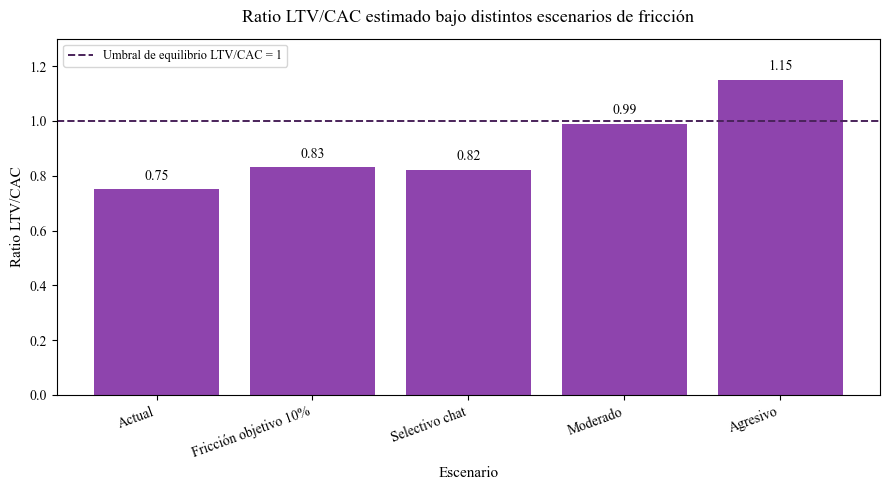

Figura guardada en: outputs\fig_ltv_cac_escenarios.png


In [40]:
# ============================================================
# Figura - Ratio LTV/CAC estimado bajo escenarios de fricción
# ============================================================

import matplotlib.pyplot as plt
from pathlib import Path

OUTPUT_PATH = Path("outputs")
OUTPUT_PATH.mkdir(exist_ok=True)

# Fuente Times New Roman
plt.rcParams["font.family"] = "Times New Roman"

# Datos finales de escenarios
ltv_cac_escenarios = pd.DataFrame({
    "escenario": [
        "Actual",
        "Fricción objetivo 10%",
        "Selectivo chat",
        "Moderado",
        "Agresivo"
    ],
    "ltv_cac": [
        0.75,
        0.83,
        0.82,
        0.99,
        1.15
    ]
})

# Orden estratégico para lectura visual
orden = [
    "Actual",
    "Fricción objetivo 10%",
    "Selectivo chat",
    "Moderado",
    "Agresivo"
]

ltv_cac_escenarios["escenario"] = pd.Categorical(
    ltv_cac_escenarios["escenario"],
    categories=orden,
    ordered=True
)

ltv_cac_escenarios = ltv_cac_escenarios.sort_values("escenario")

# Paleta morada
color_barras = "#8E44AD"
color_linea = "#4A235A"

# Crear figura
plt.figure(figsize=(9, 5))

bars = plt.bar(
    ltv_cac_escenarios["escenario"],
    ltv_cac_escenarios["ltv_cac"],
    color=color_barras
)

# Línea de equilibrio LTV/CAC = 1
plt.axhline(
    y=1,
    linestyle="--",
    linewidth=1.4,
    color=color_linea,
    label="Umbral de equilibrio LTV/CAC = 1"
)

# Etiquetas encima de las barras
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.025,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Formato
plt.title(
    "Ratio LTV/CAC estimado bajo distintos escenarios de fricción",
    fontsize=13,
    pad=12
)

plt.ylabel("Ratio LTV/CAC", fontsize=11)
plt.xlabel("Escenario", fontsize=11)

plt.ylim(0, 1.30)
plt.xticks(rotation=20, ha="right", fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=9)
plt.tight_layout()

# Guardar figura
plt.savefig("../outputs/fig_ltv_cac_escenarios.png", dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {ruta_figura}")

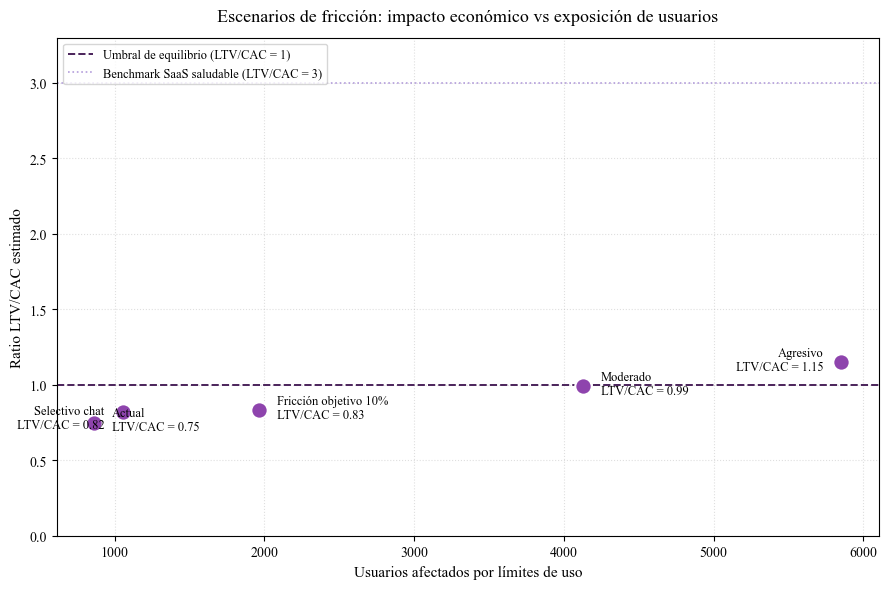

Figura guardada en: ..\outputs\fig_ltv_cac_escenarios_dispersion.png


In [41]:
# ============================================================
# Figura - LTV/CAC vs usuarios afectados por escenario
# Opción A: dispersión bidimensional (impacto económico vs riesgo de fricción)
# ============================================================
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

OUTPUT_PATH = Path("../outputs")
OUTPUT_PATH.mkdir(exist_ok=True)

plt.rcParams["font.family"] = "Times New Roman"

# Datos de escenarios (LTV/CAC + usuarios afectados según tu tabla)
escenarios = pd.DataFrame({
    "escenario": [
        "Actual",
        "Fricción objetivo 10%",
        "Selectivo chat",
        "Moderado",
        "Agresivo",
    ],
    "usuarios_afectados": [863, 1961, 1053, 4126, 5853],   # 863 actual + adicionales
    "ltv_cac": [0.75, 0.83, 0.82, 0.99, 1.15],
})

# Paleta
color_punto = "#8E44AD"
color_umbral_1 = "#4A235A"
color_umbral_3 = "#B39DDB"  # más tenue para el benchmark sectorial

fig, ax = plt.subplots(figsize=(9, 6))

# Puntos
ax.scatter(
    escenarios["usuarios_afectados"],
    escenarios["ltv_cac"],
    s=140,
    color=color_punto,
    edgecolor="white",
    linewidth=1.5,
    zorder=3,
)

# Etiquetas de cada escenario
offsets = {
    "Actual": (120, 0.015),
    "Fricción objetivo 10%": (120, 0.015),
    "Selectivo chat": (-120, -0.04),
    "Moderado": (120, 0.015),
    "Agresivo": (-120, 0.015),
}
for _, row in escenarios.iterrows():
    dx, dy = offsets[row["escenario"]]
    ha = "left" if dx > 0 else "right"
    ax.annotate(
        f"{row['escenario']}\nLTV/CAC = {row['ltv_cac']:.2f}",
        xy=(row["usuarios_afectados"], row["ltv_cac"]),
        xytext=(row["usuarios_afectados"] + dx, row["ltv_cac"] + dy),
        fontsize=9,
        ha=ha,
        va="center",
    )

# Líneas de referencia
ax.axhline(y=1, linestyle="--", linewidth=1.4, color=color_umbral_1,
           label="Umbral de equilibrio (LTV/CAC = 1)")
ax.axhline(y=3, linestyle=":", linewidth=1.2, color=color_umbral_3,
           label="Benchmark SaaS saludable (LTV/CAC = 3)")

# Formato
ax.set_title(
    "Escenarios de fricción: impacto económico vs exposición de usuarios",
    fontsize=13, pad=12,
)
ax.set_xlabel("Usuarios afectados por límites de uso", fontsize=11)
ax.set_ylabel("Ratio LTV/CAC estimado", fontsize=11)
ax.set_ylim(0, 3.3)
ax.grid(True, linestyle=":", alpha=0.4)
ax.legend(fontsize=9, loc="upper left")

plt.tight_layout()
plt.savefig(OUTPUT_PATH / "fig_ltv_cac_escenarios_dispersion.png",
            dpi=300, bbox_inches="tight")
plt.show()
print(f"Figura guardada en: {OUTPUT_PATH / 'fig_ltv_cac_escenarios_dispersion.png'}")

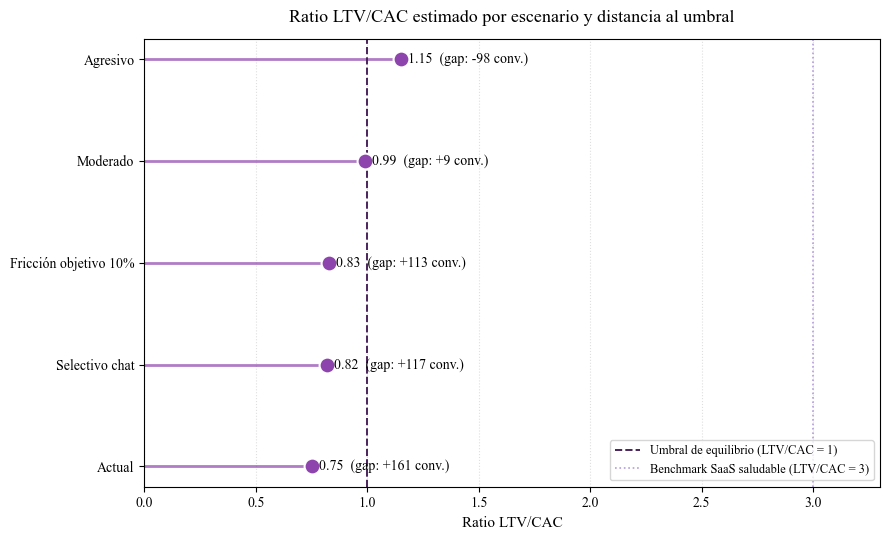

Figura guardada en: ..\outputs\fig_ltv_cac_escenarios_lollipop.png


In [42]:
# ============================================================
# Figura - Ratio LTV/CAC por escenario con gap al umbral
# Opción B: lollipop horizontal ordenado
# ============================================================
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

OUTPUT_PATH = Path("../outputs")
OUTPUT_PATH.mkdir(exist_ok=True)

plt.rcParams["font.family"] = "Times New Roman"

# Datos: LTV/CAC + gap de conversiones al umbral LTV/CAC = 1
escenarios = pd.DataFrame({
    "escenario": [
        "Actual",
        "Selectivo chat",
        "Fricción objetivo 10%",
        "Moderado",
        "Agresivo",
    ],
    "ltv_cac": [0.75, 0.82, 0.83, 0.99, 1.15],
    "gap": [161, 117, 113, 9, -98],  # conversiones que faltan (o sobran) al umbral
})
# Orden ascendente para lectura natural
escenarios = escenarios.sort_values("ltv_cac").reset_index(drop=True)

# Paleta
color_punto = "#8E44AD"
color_linea = "#8E44AD"
color_umbral_1 = "#4A235A"
color_umbral_3 = "#B39DDB"

fig, ax = plt.subplots(figsize=(9, 5.5))

# Lollipops horizontales
ax.hlines(
    y=escenarios["escenario"],
    xmin=0,
    xmax=escenarios["ltv_cac"],
    color=color_linea,
    linewidth=2,
    alpha=0.7,
)
ax.scatter(
    escenarios["ltv_cac"],
    escenarios["escenario"],
    s=130,
    color=color_punto,
    edgecolor="white",
    linewidth=1.5,
    zorder=3,
)

# Etiqueta de valor + gap al lado del punto
for _, row in escenarios.iterrows():
    signo = "+" if row["gap"] > 0 else ""
    texto = f"  {row['ltv_cac']:.2f}  (gap: {signo}{int(row['gap'])} conv.)"
    ax.text(
        row["ltv_cac"], row["escenario"],
        texto,
        va="center", ha="left",
        fontsize=10,
    )

# Líneas de referencia
ax.axvline(x=1, linestyle="--", linewidth=1.4, color=color_umbral_1,
           label="Umbral de equilibrio (LTV/CAC = 1)")
ax.axvline(x=3, linestyle=":", linewidth=1.2, color=color_umbral_3,
           label="Benchmark SaaS saludable (LTV/CAC = 3)")

# Formato
ax.set_title(
    "Ratio LTV/CAC estimado por escenario y distancia al umbral",
    fontsize=13, pad=12,
)
ax.set_xlabel("Ratio LTV/CAC", fontsize=11)
ax.set_ylabel("")
ax.set_xlim(0, 3.3)
ax.grid(True, axis="x", linestyle=":", alpha=0.4)
ax.legend(fontsize=9, loc="lower right")

plt.tight_layout()
plt.savefig(OUTPUT_PATH / "fig_ltv_cac_escenarios_lollipop.png",
            dpi=300, bbox_inches="tight")
plt.show()
print(f"Figura guardada en: {OUTPUT_PATH / 'fig_ltv_cac_escenarios_lollipop.png'}")

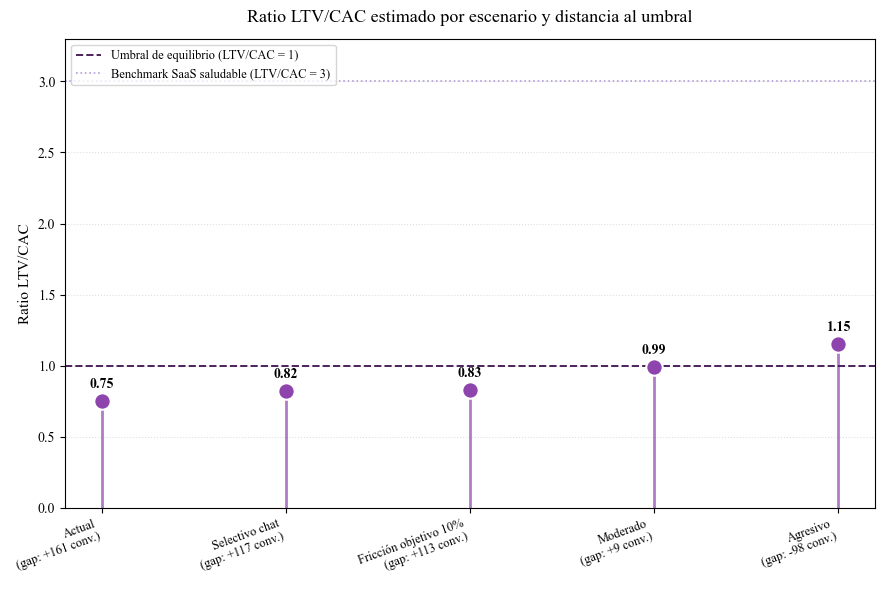

Figura guardada en: ..\outputs\fig_ltv_cac_escenarios_lollipop.png


In [43]:
# ============================================================
# Figura - Ratio LTV/CAC por escenario con gap al umbral
# Lollipop vertical ordenado
# ============================================================
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

OUTPUT_PATH = Path("../outputs")
OUTPUT_PATH.mkdir(exist_ok=True)

plt.rcParams["font.family"] = "Times New Roman"

# Datos: LTV/CAC + gap de conversiones al umbral LTV/CAC = 1
escenarios = pd.DataFrame({
    "escenario": [
        "Actual",
        "Selectivo chat",
        "Fricción objetivo 10%",
        "Moderado",
        "Agresivo",
    ],
    "ltv_cac": [0.75, 0.82, 0.83, 0.99, 1.15],
    "gap": [161, 117, 113, 9, -98],
})
# Orden ascendente para lectura izquierda-derecha
escenarios = escenarios.sort_values("ltv_cac").reset_index(drop=True)

# Paleta
color_punto = "#8E44AD"
color_linea = "#8E44AD"
color_umbral_1 = "#4A235A"
color_umbral_3 = "#B39DDB"

fig, ax = plt.subplots(figsize=(9, 6))

# Lollipops verticales
ax.vlines(
    x=escenarios["escenario"],
    ymin=0,
    ymax=escenarios["ltv_cac"],
    color=color_linea,
    linewidth=2,
    alpha=0.7,
)
ax.scatter(
    escenarios["escenario"],
    escenarios["ltv_cac"],
    s=140,
    color=color_punto,
    edgecolor="white",
    linewidth=1.5,
    zorder=3,
)

# Valor de LTV/CAC encima de cada punto
for _, row in escenarios.iterrows():
    ax.text(
        row["escenario"], row["ltv_cac"] + 0.07,
        f"{row['ltv_cac']:.2f}",
        ha="center", va="bottom",
        fontsize=10, fontweight="bold",
    )

# Líneas de referencia
ax.axhline(y=1, linestyle="--", linewidth=1.4, color=color_umbral_1,
           label="Umbral de equilibrio (LTV/CAC = 1)")
ax.axhline(y=3, linestyle=":", linewidth=1.2, color=color_umbral_3,
           label="Benchmark SaaS saludable (LTV/CAC = 3)")

# Etiquetas del eje X con escenario + gap en dos líneas
etiquetas_x = [
    f"{row['escenario']}\n(gap: {'+' if row['gap']>0 else ''}{int(row['gap'])} conv.)"
    for _, row in escenarios.iterrows()
]
ax.set_xticks(range(len(escenarios)))
ax.set_xticklabels(etiquetas_x, rotation=20, ha="right", fontsize=9)

# Formato
ax.set_title(
    "Ratio LTV/CAC estimado por escenario y distancia al umbral",
    fontsize=13, pad=12,
)
ax.set_ylabel("Ratio LTV/CAC", fontsize=11)
ax.set_xlabel("")
ax.set_ylim(0, 3.3)
ax.grid(True, axis="y", linestyle=":", alpha=0.4)
ax.legend(fontsize=9, loc="upper left")

plt.tight_layout()
plt.savefig(OUTPUT_PATH / "fig_ltv_cac_escenarios_lollipop.png",
            dpi=300, bbox_inches="tight")
plt.show()
print(f"Figura guardada en: {OUTPUT_PATH / 'fig_ltv_cac_escenarios_lollipop.png'}")

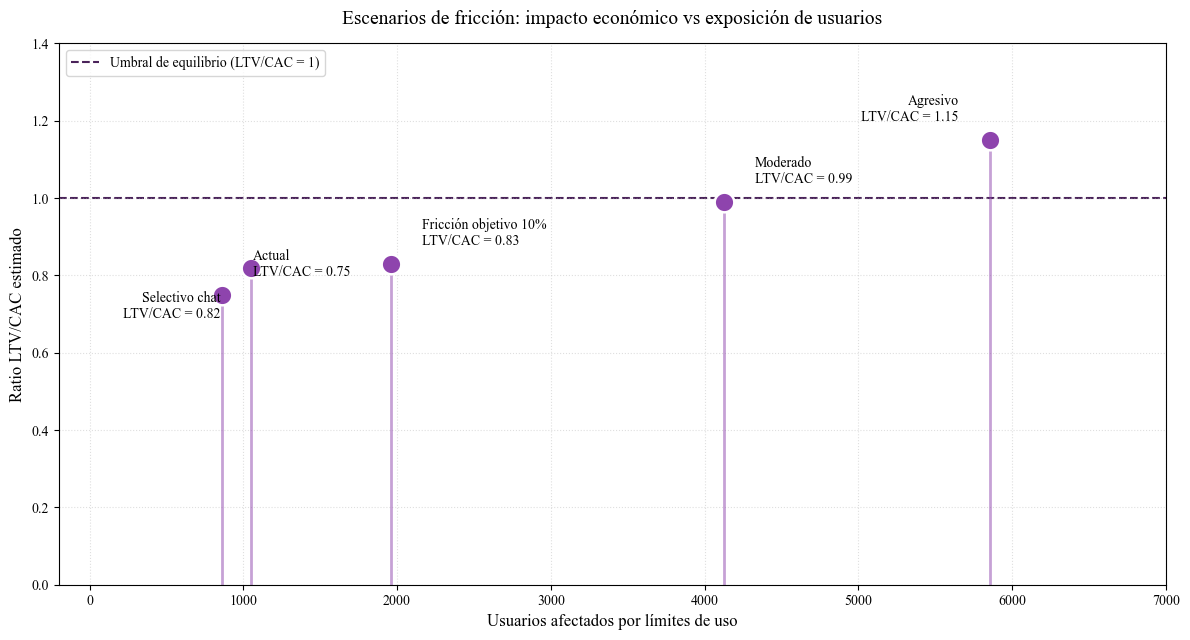

Figura guardada en: ..\outputs\fig_ltv_cac_escenarios_dispersion_lollipop.png


In [47]:
# ============================================================
# Figura - LTV/CAC vs usuarios afectados por escenario
# Dispersión bidimensional con lollipops verticales (ajustada)
# ============================================================
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

OUTPUT_PATH = Path("../outputs")
OUTPUT_PATH.mkdir(exist_ok=True)

plt.rcParams["font.family"] = "Times New Roman"

# Datos de escenarios
escenarios = pd.DataFrame({
    "escenario": [
        "Actual",
        "Fricción objetivo 10%",
        "Selectivo chat",
        "Moderado",
        "Agresivo",
    ],
    "usuarios_afectados": [863, 1961, 1053, 4126, 5853],
    "ltv_cac": [0.75, 0.83, 0.82, 0.99, 1.15],
})

# Paleta
color_punto = "#8E44AD"
color_linea = "#8E44AD"
color_umbral_1 = "#4A235A"

fig, ax = plt.subplots(figsize=(12, 6.5))

# Palos del lollipop
ax.vlines(
    x=escenarios["usuarios_afectados"],
    ymin=0,
    ymax=escenarios["ltv_cac"],
    color=color_linea,
    linewidth=2,
    alpha=0.5,
    zorder=2,
)

# Cabezas del lollipop
ax.scatter(
    escenarios["usuarios_afectados"],
    escenarios["ltv_cac"],
    s=200,
    color=color_punto,
    edgecolor="white",
    linewidth=1.8,
    zorder=4,
)

# Etiquetas — desplazadas para no solapar
offsets = {
    "Actual":                 (200,  0.08),
    "Fricción objetivo 10%":  (200,  0.08),
    "Selectivo chat":         (-200, -0.10),
    "Moderado":               (200,  0.08),
    "Agresivo":               (-200, 0.08),
}
for _, row in escenarios.iterrows():
    dx, dy = offsets[row["escenario"]]
    ha = "left" if dx > 0 else "right"
    ax.annotate(
        f"{row['escenario']}\nLTV/CAC = {row['ltv_cac']:.2f}",
        xy=(row["usuarios_afectados"], row["ltv_cac"]),
        xytext=(row["usuarios_afectados"] + dx, row["ltv_cac"] + dy),
        fontsize=10,
        ha=ha,
        va="center",
        zorder=5,
    )

# Línea de equilibrio
ax.axhline(y=1, linestyle="--", linewidth=1.5, color=color_umbral_1,
           label="Umbral de equilibrio (LTV/CAC = 1)", zorder=1)

# Formato
ax.set_title(
    "Escenarios de fricción: impacto económico vs exposición de usuarios",
    fontsize=14, pad=14,
)
ax.set_xlabel("Usuarios afectados por límites de uso", fontsize=12)
ax.set_ylabel("Ratio LTV/CAC estimado", fontsize=12)
ax.set_ylim(0, 1.4)
ax.set_xlim(-200, 7000)
ax.grid(True, linestyle=":", alpha=0.4)
ax.legend(fontsize=10, loc="upper left")
ax.tick_params(axis="both", labelsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_PATH / "fig_ltv_cac_escenarios_dispersion_lollipop.png",
            dpi=300, bbox_inches="tight")
plt.show()
print(f"Figura guardada en: {OUTPUT_PATH / 'fig_ltv_cac_escenarios_dispersion_lollipop.png'}")